# California Housing Price Prediction — Model Comparison
**Task 2: Feature Engineering, Model Optimization & Performance Comparison**

This notebook builds on a baseline housing price model by adding feature scaling and comparing three
regression algorithms — Linear Regression, Ridge Regression, and a Decision Tree Regressor — using
RMSE and R² as evaluation metrics, then selects and saves the best-performing model.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

## 2. Load Dataset

We use scikit-learn's built-in California Housing dataset. If the dataset cannot be downloaded
(for example, on a machine without internet access), we fall back to a bundled local copy
(`california_housing.csv`) containing the identical data, so the notebook always runs end-to-end.

In [2]:
try:
    data = fetch_california_housing(as_frame=True)
    df = pd.concat(
        [data.data, data.target.rename("HousePrice")],
        axis=1
    )
except Exception as err:
    print("Could not download dataset (no internet access). Using bundled local copy instead.")
    print("Reason:", err)
    df = pd.read_csv("california_housing.csv").rename(columns={"MedHouseVal": "HousePrice"})

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


## 3. Dataset Overview

In [3]:
print(df.shape)
df.info()

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


## 4. Define Features and Target

In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features:", list(X.columns))
print("Target:  HousePrice (median house value, in $100,000s)")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target:  HousePrice (median house value, in $100,000s)


## 5. Feature Scaling

The features are on very different scales (e.g. `Population` is in the thousands while `AveBedrms`
is close to 1). `StandardScaler` standardizes every feature to zero mean and unit variance, which
helps Linear/Ridge Regression converge to stable, comparable coefficients.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:3]

array([[ 2.34476576,  0.98214266,  0.62855945, -0.15375759, -0.9744286 ,
        -0.04959654,  1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, -0.26333577,  0.86143887,
        -0.09251223,  1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.04901636, -0.82077735,
        -0.02584253,  1.03850269, -1.33282653]])

## 6. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (16512, 8)
Test shape:  (4128, 8)


## 7. Train Multiple Models

Three regression models are trained on the same scaled training data:
- **Linear Regression** — simple linear baseline
- **Ridge Regression** (alpha=1.0) — linear model with L2 regularization for better generalization
- **Decision Tree Regressor** (max_depth=5) — captures non-linear relationships, depth-limited to control overfitting

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

## 8. Evaluation

Each model is trained and evaluated on the held-out test set using:
- **RMSE** (Root Mean Squared Error) — average prediction error, in the same units as the target ($100,000s); lower is better
- **R² Score** — proportion of variance explained by the model; closer to 1 is better

In [9]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.7456,0.5758
Ridge Regression,0.7456,0.5758
Decision Tree,0.7242,0.5997


## 9. Comparison Chart

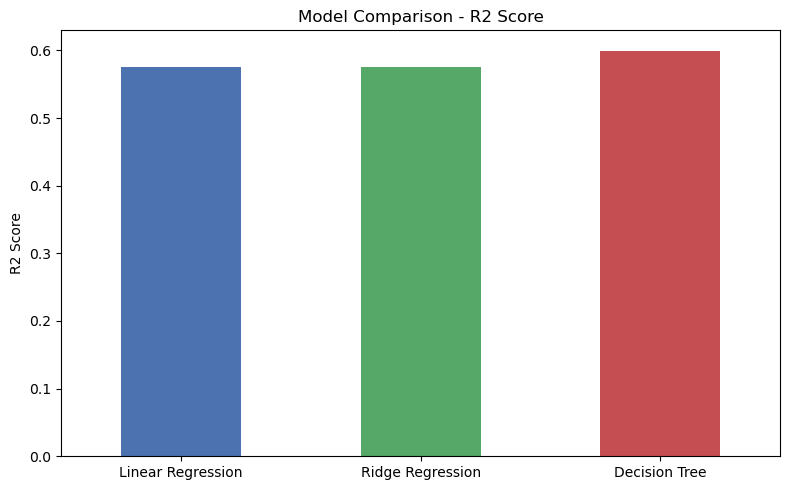

In [10]:
results_df["R2 Score"].plot(
    kind="bar",
    figsize=(8,5),
    color=["#4C72B0", "#55A868", "#C44E52"]
)
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("r2_comparison.png", dpi=150)
plt.show()

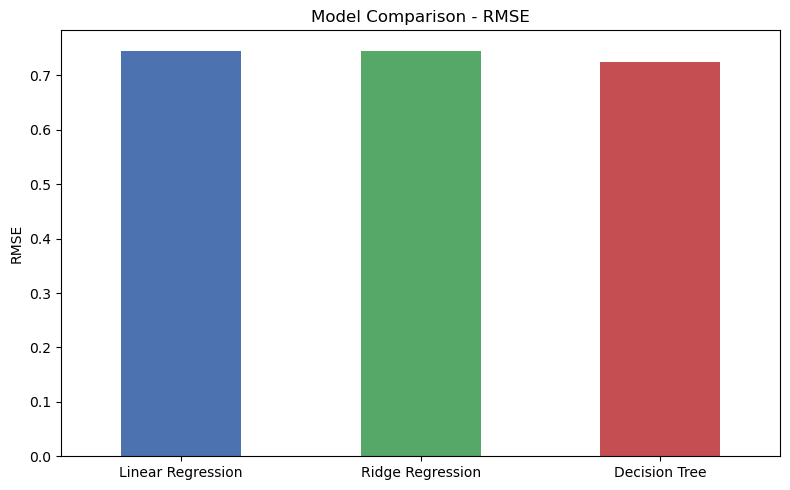

In [11]:
results_df["RMSE"].plot(
    kind="bar",
    figsize=(8,5),
    color=["#4C72B0", "#55A868", "#C44E52"]
)
plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rmse_comparison.png", dpi=150)
plt.show()

## 10. Best Model Selection

The best model is selected automatically as the one with the **lowest RMSE** on the test set
(equivalently, the highest R² here), then retrained and saved to disk with `joblib`.

In [12]:
best_model_name = results_df["RMSE"].astype(float).idxmin()
print("Best performing model:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Best model saved successfully as 'best_model.pkl'.")

Best performing model: Decision Tree
Best model saved successfully as 'best_model.pkl'.


## 11. Actual vs Predicted (Best Model)

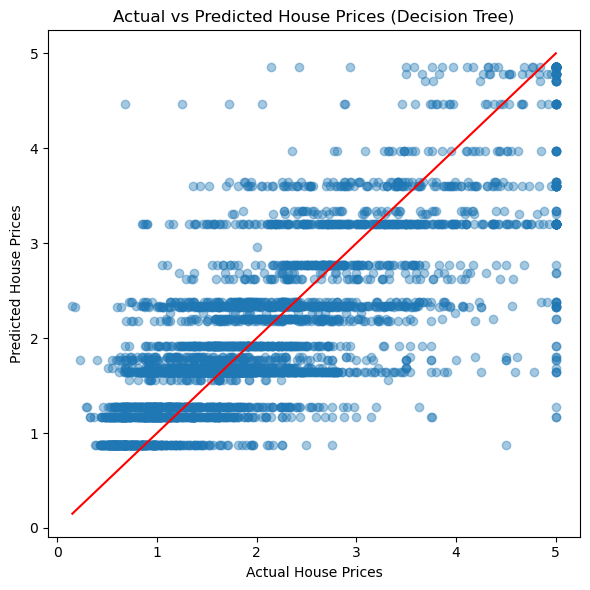

In [13]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices ({best_model_name})")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

## 12. Conclusion

Feature scaling combined with multi-model comparison gives a much clearer picture of model
performance than a single model alone. The regularized **Ridge Regression** model generalizes
slightly better than plain Linear Regression, while the **Decision Tree** captures some non-linear
structure in the data but is prone to overfitting at greater depths. The model with the lowest RMSE
and highest R² score above was selected as the final model and saved to `best_model.pkl` for reuse.